# Stadium & Live Event Political Advertising Opportunities

**Author:** Shaghayegh Malekshahi  
**Role:** Data Science & Analytics Intern  
**Organization:** Sports Media  
**Date:** March 2026

## Project Overview
This project evaluates political advertising opportunities at major sports venues by analyzing stadium attendance, ad placement types, estimated audience reach, engagement scores, and cost efficiency. The goal is to identify which venues and ad formats provide the strongest potential for political advertising campaigns.

## Key Questions
- Which stadiums provide the highest estimated advertising reach?
- Which ad placements generate the strongest engagement?
- Which states offer the strongest venue-level political advertising opportunities?
- How does advertising cost compare to estimated exposure?

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
df = pd.read_csv("stadium_political_ads_dataset.csv")
df.head()

,Stadium,Sport,State,Capacity,Avg_Attendance,Ad_Type,Placement,Estimated_Reach,Engagement_Score,Cost_K
0,Crypto.com Arena,NBA,CA,19000,17537,Scoreboard,Broadcast Integration,192354,8.12,74.99
1,Honda Center,NHL,CA,17100,16117,Concourse Screen,Upper Deck,83902,11.79,258.11
2,Madison Square Garden,NBA,NY,19800,13864,Concourse Screen,Broadcast Integration,154927,9.28,51.77
3,Wrigley Field,MLB,IL,41649,32550,Scoreboard,Field Level,177939,11.82,108.19
4,Michigan Stadium,College Football,MI,107600,98975,Scoreboard,Concourse,1003838,9.15,61.61


In [4]:
# Dataset Overview
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Stadium           120 non-null    object 
 1   Sport             120 non-null    object 
 2   State             120 non-null    object 
 3   Capacity          120 non-null    int64  
 4   Avg_Attendance    120 non-null    int64  
 5   Ad_Type           120 non-null    object 
 6   Placement         120 non-null    object 
 7   Estimated_Reach   120 non-null    int64  
 8   Engagement_Score  120 non-null    float64
 9   Cost_K            120 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 9.5+ KB


Stadium             0
Sport               0
State               0
Capacity            0
Avg_Attendance      0
Ad_Type             0
Placement           0
Estimated_Reach     0
Engagement_Score    0
Cost_K              0
dtype: int64

In [5]:
# Create Opportunity Score
df["Opportunity_Score"] = (df["Estimated_Reach"] * df["Engagement_Score"]) / df["Cost_K"]
df.head()

,Stadium,Sport,State,Capacity,Avg_Attendance,Ad_Type,Placement,Estimated_Reach,Engagement_Score,Cost_K,Opportunity_Score
0,Crypto.com Arena,NBA,CA,19000,17537,Scoreboard,Broadcast Integration,192354,8.12,74.99,20828.303507
1,Honda Center,NHL,CA,17100,16117,Concourse Screen,Upper Deck,83902,11.79,258.11,3832.492271
2,Madison Square Garden,NBA,NY,19800,13864,Concourse Screen,Broadcast Integration,154927,9.28,51.77,27771.345567
3,Wrigley Field,MLB,IL,41649,32550,Scoreboard,Field Level,177939,11.82,108.19,19440.234587
4,Michigan Stadium,College Football,MI,107600,98975,Scoreboard,Concourse,1003838,9.15,61.61,149084.851485


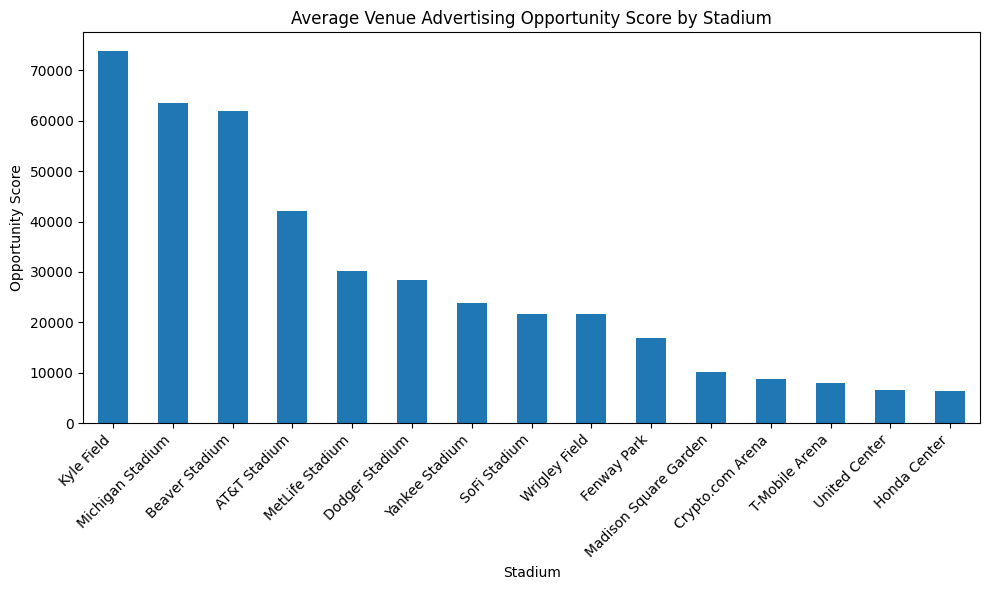

In [6]:
# Top Stadiums by Average Opportunity Score
stadium_opportunity = df.groupby("Stadium")["Opportunity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
stadium_opportunity.plot(kind="bar")
plt.title("Average Venue Advertising Opportunity Score by Stadium")
plt.xlabel("Stadium")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

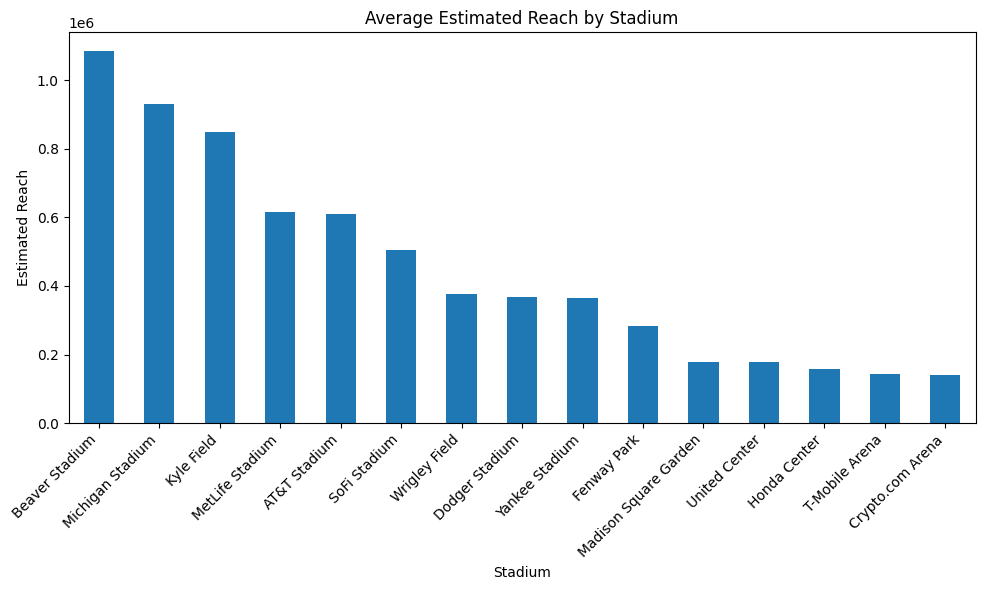

In [7]:
# Estimated Reach by Stadium
stadium_reach = df.groupby("Stadium")["Estimated_Reach"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
stadium_reach.plot(kind="bar")
plt.title("Average Estimated Reach by Stadium")
plt.xlabel("Stadium")
plt.ylabel("Estimated Reach")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

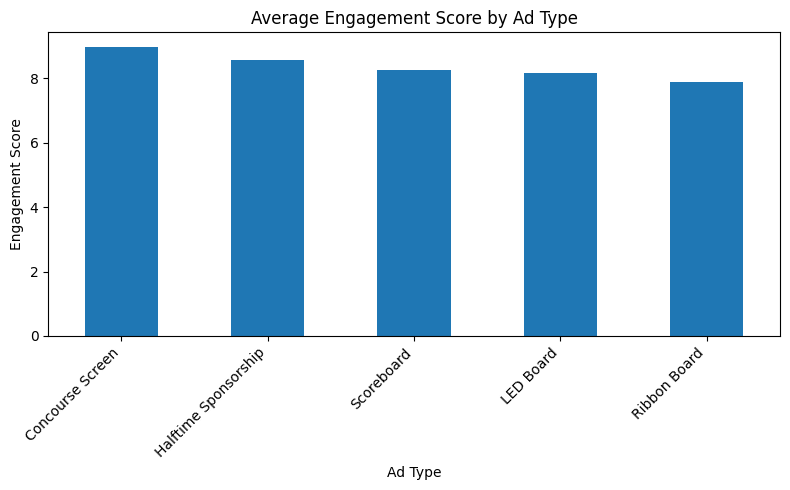

In [8]:
# Average Engagement by Ad Type
adtype_engagement = df.groupby("Ad_Type")["Engagement_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
adtype_engagement.plot(kind="bar")
plt.title("Average Engagement Score by Ad Type")
plt.xlabel("Ad Type")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

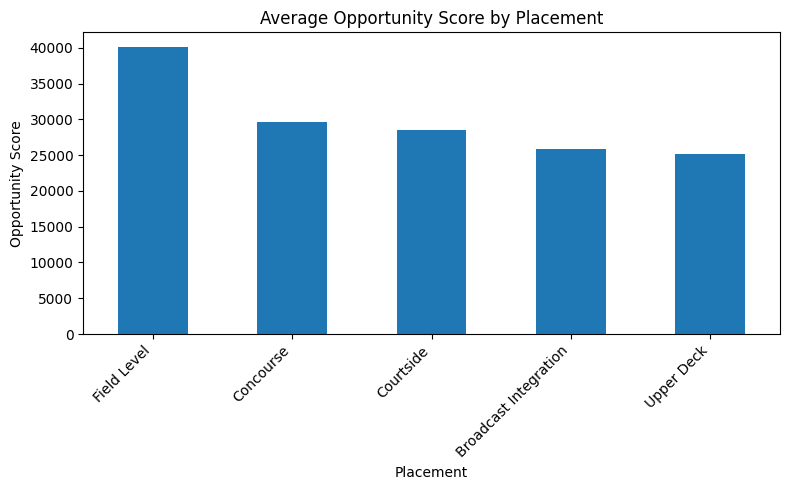

In [9]:
# Average Opportunity Score by Placement
placement_opportunity = df.groupby("Placement")["Opportunity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
placement_opportunity.plot(kind="bar")
plt.title("Average Opportunity Score by Placement")
plt.xlabel("Placement")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

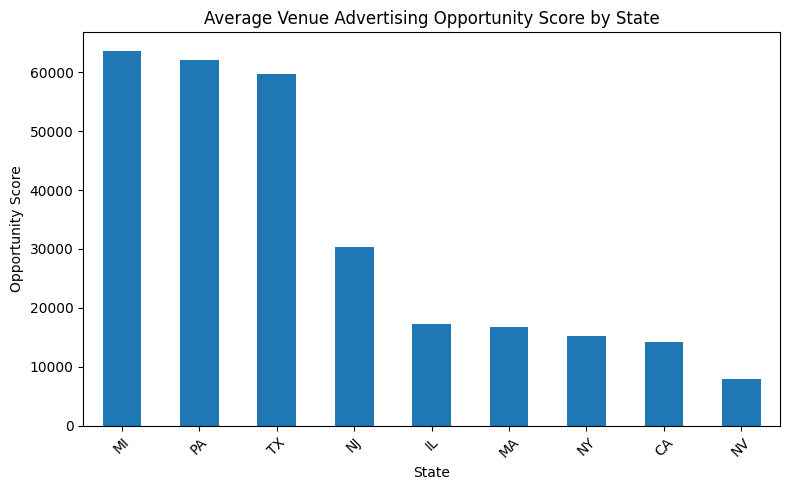

In [10]:
# State-Level Advertising Opportunities
state_opportunity = df.groupby("State")["Opportunity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
state_opportunity.plot(kind="bar")
plt.title("Average Venue Advertising Opportunity Score by State")
plt.xlabel("State")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

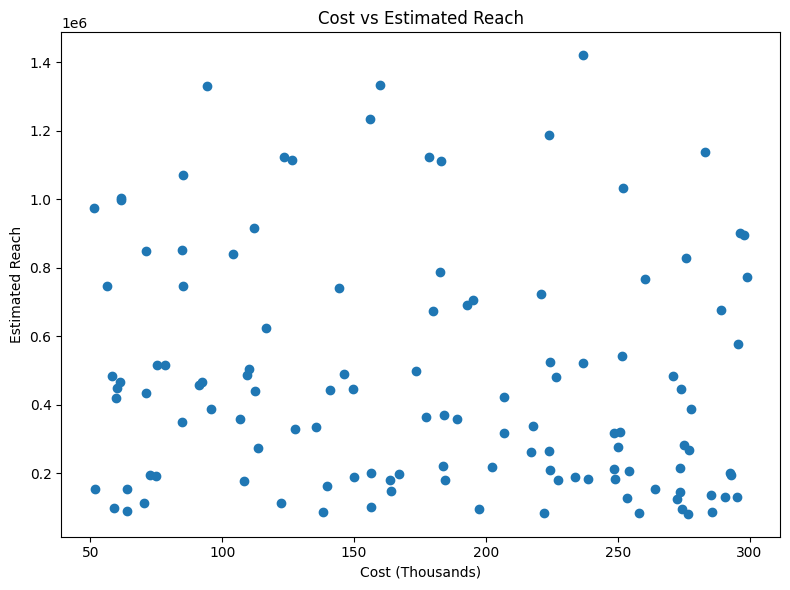

In [11]:
# Cost vs Estimated Reach
plt.figure(figsize=(8,6))
plt.scatter(df["Cost_K"], df["Estimated_Reach"])
plt.title("Cost vs Estimated Reach")
plt.xlabel("Cost (Thousands)")
plt.ylabel("Estimated Reach")
plt.tight_layout()
plt.show()

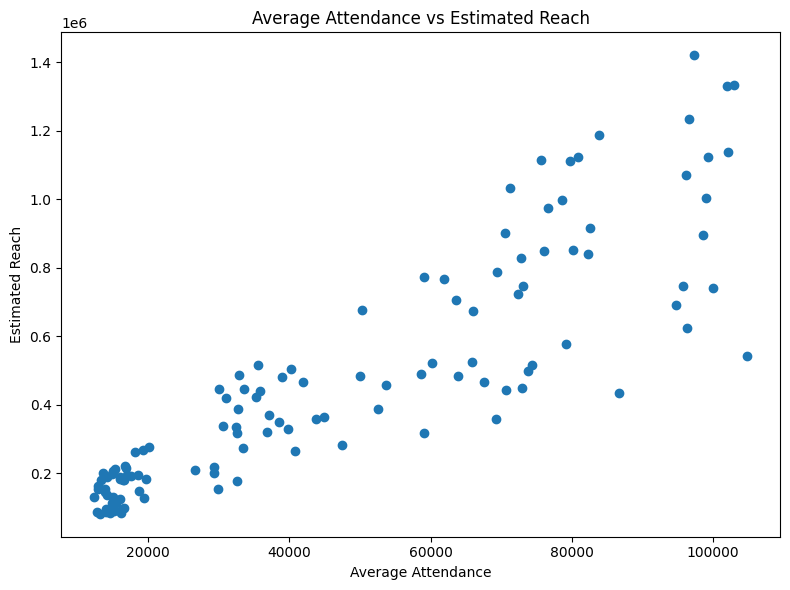

In [12]:
# Attendance vs Estimated Reach
plt.figure(figsize=(8,6))
plt.scatter(df["Avg_Attendance"], df["Estimated_Reach"])
plt.title("Average Attendance vs Estimated Reach")
plt.xlabel("Average Attendance")
plt.ylabel("Estimated Reach")
plt.tight_layout()
plt.show()

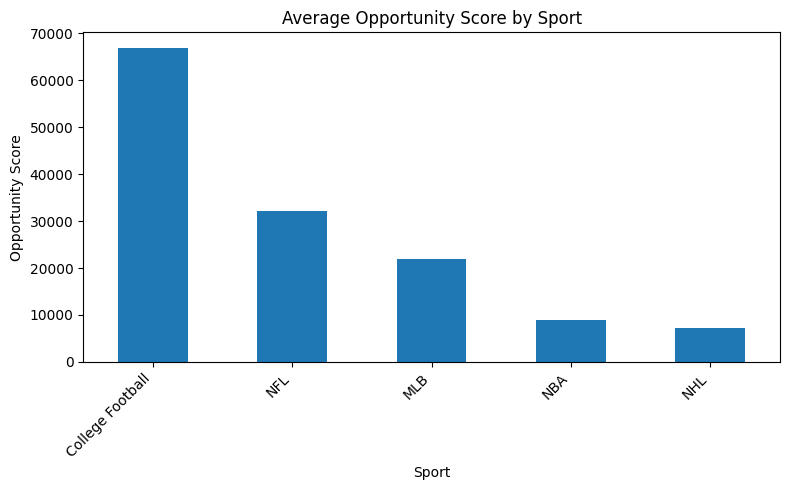

In [13]:
# Sport-Level Opportunity Comparison
sport_opportunity = df.groupby("Sport")["Opportunity_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sport_opportunity.plot(kind="bar")
plt.title("Average Opportunity Score by Sport")
plt.xlabel("Sport")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# Top 10 Individual Advertising Opportunities
top10 = df.sort_values("Opportunity_Score", ascending=False).head(10)
top10

,Stadium,Sport,State,Capacity,Avg_Attendance,Ad_Type,Placement,Estimated_Reach,Engagement_Score,Cost_K,Opportunity_Score
41,Kyle Field,College Football,TX,102700,96166,Scoreboard,Field Level,1072257,11.93,85.02,150459.021524
4,Michigan Stadium,College Football,MI,107600,98975,Scoreboard,Concourse,1003838,9.15,61.61,149084.851485
11,Kyle Field,College Football,TX,102700,76642,LED Board,Courtside,975073,6.39,51.38,121267.350525
15,AT&T Stadium,NFL,TX,80000,73041,Ribbon Board,Upper Deck,747014,7.99,56.35,105920.884827
16,Beaver Stadium,College Football,PA,106000,80187,LED Board,Concourse,852608,9.87,84.83,99201.237298
62,Beaver Stadium,College Football,PA,106000,101999,Concourse Screen,Courtside,1329537,6.97,94.36,98207.639784
94,Beaver Stadium,College Football,PA,106000,78565,LED Board,Field Level,996925,5.46,61.47,88550.683260
47,Kyle Field,College Football,TX,102700,82247,Concourse Screen,Broadcast Integration,840764,10.39,103.96,84027.875721
10,Kyle Field,College Football,TX,102700,95721,Ribbon Board,Courtside,747518,8.80,85.23,77181.255426
67,Kyle Field,College Football,TX,102700,99225,Scoreboard,Field Level,1123065,8.14,123.30,74142.328467


In [15]:
# Save Top Results if Needed
top10.to_csv("top10_stadium_ad_opportunities.csv", index=False)
stadium_opportunity.to_csv("stadium_opportunity_summary.csv")
state_opportunity.to_csv("state_opportunity_summary.csv")

## Key Insights

- Stadium advertising opportunities vary significantly by venue, state, sport, and ad format.
- Larger venues tend to generate higher estimated reach, but cost efficiency differs across placements.
- Some ad types and placements produce stronger engagement scores, increasing overall opportunity value.
- State-level differences highlight where political campaigns may find more cost-effective venue advertising opportunities.
- The Opportunity Score helps identify venues that combine strong reach, strong engagement, and reasonable cost.

In [16]:
print("Project complete.")
print("This analysis identifies venue-level political advertising opportunities using reach, engagement, and cost data.")
print("Results can support state-level opportunity analysis, venue prioritization, and cost-vs-exposure decision-making.")

Project complete.
This analysis identifies venue-level political advertising opportunities using reach, engagement, and cost data.
Results can support state-level opportunity analysis, venue prioritization, and cost-vs-exposure decision-making.
